# IPL Data Analysis (2008-2025)

## Overview
Exploratory Data Analysis on 18 seasons of IPL cricket data covering
1169 matches, 19 teams and top players across all seasons.

## Key Findings
- Mumbai Indians are the most successful team with 151 wins
- Virat Kohli leads all-time run scorers with 8,671 runs
- Yuzvendra Chahal is the top wicket taker with 221 wickets
- 65.4% of captains choose to field first after winning the toss
- Chris Gayle is the all-time six hitting king with 359 sixes
- AB de Villiers leads Player of the Match awards with 25

## Tools Used
Python, Pandas, Matplotlib, Seaborn, Google Colab

In [5]:
from google.colab import files
uploaded = files.upload()


Saving deliveries.csv to deliveries.csv
Saving IPL.csv to IPL.csv


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv('IPL.csv')


print("Matches dataset shape:", matches.shape)


/tmp/ipykernel_169/3841002058.py:5: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  matches = pd.read_csv('IPL.csv')


Matches dataset shape: (278205, 64)


In [8]:
print("IPL.csv columns:")
print(matches.columns.tolist())



IPL.csv columns:
['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs', 'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter', 'striker_out']


In [9]:
matches.head()

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [10]:
# Check basic info
print("Seasons covered:", matches['season'].unique())
print("Total matches:", matches['match_id'].nunique())
print("Total teams:", matches['batting_team'].nunique())

Seasons covered: ['2007/08' '2009' 2009 '2009/10' '2011' 2011 2012 2013 2014 2015 2016 2017
 2018 2019 '2019' '2020/21' '2021' 2021 2022 2023 2024 2025]
Total matches: 1169
Total teams: 19


In [11]:
# Clean the season column
matches['season'] = matches['season'].astype(str).str.strip()

# Standardize mixed season formats
season_map = {
    '2007/08': '2008',
    '2009/10': '2010',
    '2020/21': '2020'
}
matches['season'] = matches['season'].replace(season_map)

# Remove .0 if any float crept in
matches['season'] = matches['season'].str.replace('.0', '', regex=False)

# Verify
print("Cleaned seasons:", sorted(matches['season'].unique()))
print("Total seasons:", matches['season'].nunique())

Cleaned seasons: ['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']
Total seasons: 18


/tmp/ipykernel_169/2293668016.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=matches_per_season.index, y=matches_per_season.values, palette='Blues_d')


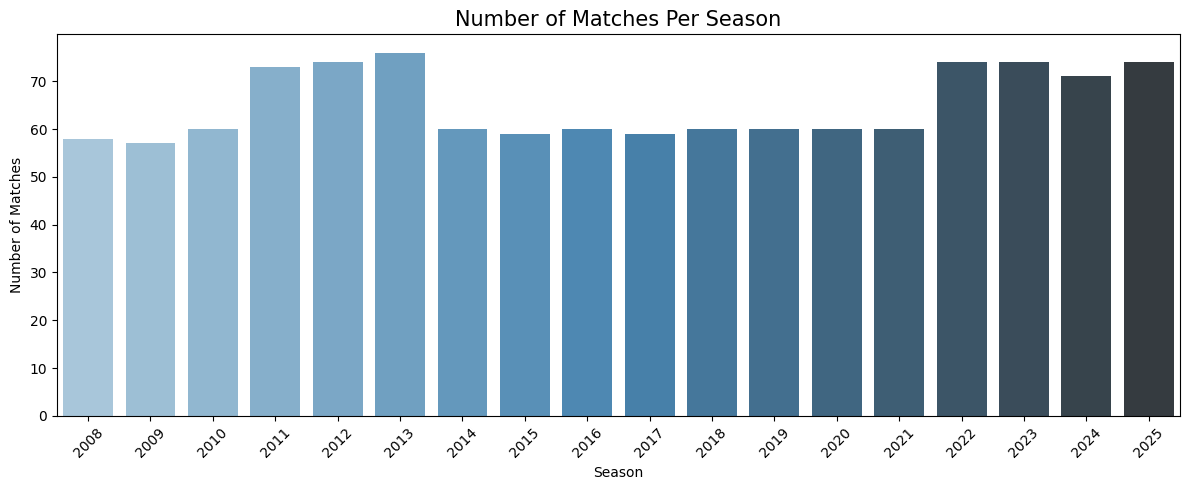

season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
2020    60
2021    60
2022    74
2023    74
2024    71
2025    74
Name: match_id, dtype: int64


In [12]:
# matches per season
matches_per_season = matches.groupby('season')['match_id'].nunique()

plt.figure(figsize=(12,5))
sns.barplot(x=matches_per_season.index, y=matches_per_season.values, palette='Blues_d')
plt.title('Number of Matches Per Season', fontsize=15)
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(matches_per_season)

IPL started with 58 matches in 2008 and has grown to 74 matches in 2025,
covering 18 seasons. 2013 had the most matches (76) due to a larger team
pool. 2014 and 2015 saw a dip as Pune Warriors and Kochi Tuskers were
removed from the league.

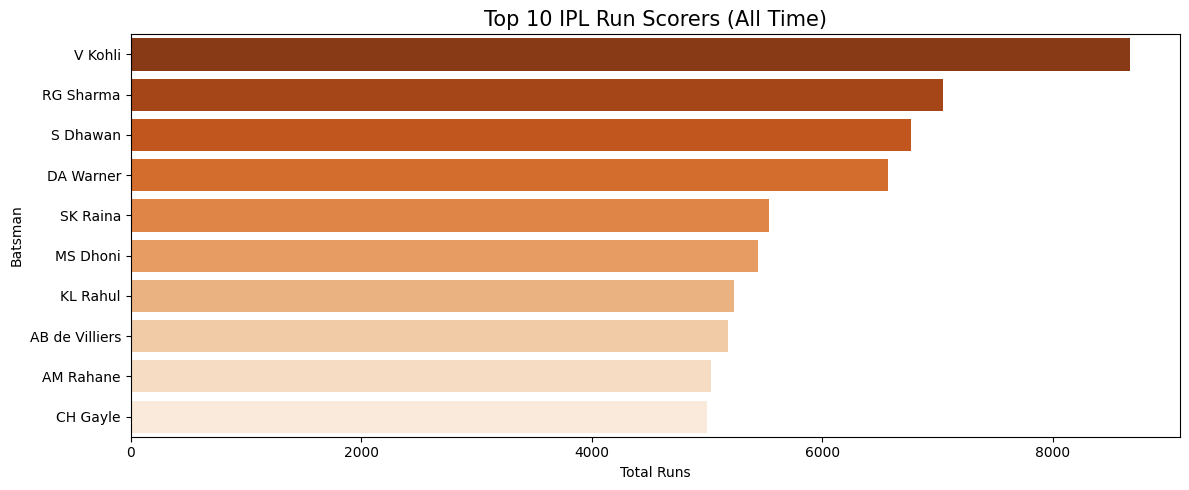

In [13]:
top_batsmen = matches.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index, hue=top_batsmen.index, palette='Oranges_r', legend=False)
plt.title('Top 10 IPL Run Scorers (All Time)', fontsize=15)
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()



Virat Kohli leads all-time IPL run scorers with 8,671 runs — over 1,600
runs ahead of Rohit Sharma (7,048). Interestingly, 4 out of top 10
batsmen are openers, highlighting how crucial the powerplay is in T20 cricket.

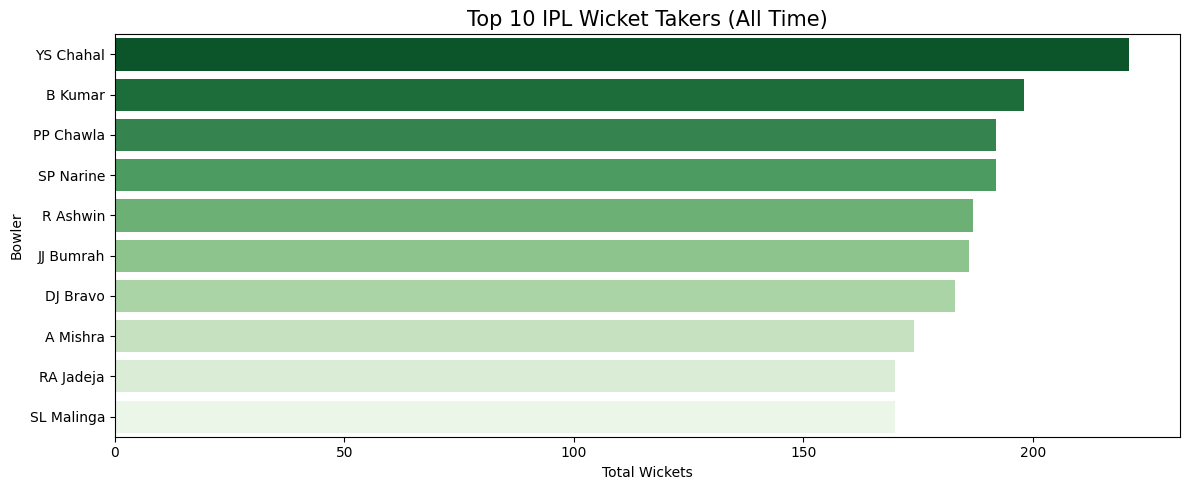

bowler
YS Chahal     221
B Kumar       198
PP Chawla     192
SP Narine     192
R Ashwin      187
JJ Bumrah     186
DJ Bravo      183
A Mishra      174
RA Jadeja     170
SL Malinga    170
Name: wicket_kind, dtype: int64


In [14]:
# Top 10 bowlers by wickets
wickets = matches[matches['wicket_kind'].notna() &
                  ~matches['wicket_kind'].isin(['run out', 'retired hurt', 'obstructing the field'])]

top_bowlers = wickets.groupby('bowler')['wicket_kind'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, hue=top_bowlers.index, palette='Greens_r', legend=False)
plt.title('Top 10 IPL Wicket Takers (All Time)', fontsize=15)
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

print(top_bowlers)

Yuzvendra Chahal leads all-time IPL wicket takers with 221 wickets,
followed by Bhuvneshwar Kumar (198). Spinners dominate the top 10
with Chahal, Chawla, Narine, Ashwin, Mishra and Jadeja all featuring,
proving that spin bowling is a crucial weapon in IPL conditions.

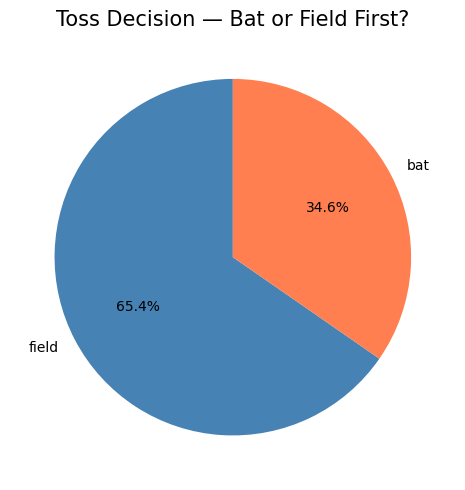

toss_decision
field    764
bat      405
Name: count, dtype: int64


In [15]:
# Toss decision - bat or field?
toss_decision = matches.drop_duplicates('match_id')['toss_decision'].value_counts()

plt.figure(figsize=(7,5))
plt.pie(toss_decision.values, labels=toss_decision.index, autopct='%1.1f%%',
        colors=['steelblue', 'coral'], startangle=90)
plt.title('Toss Decision — Bat or Field First?', fontsize=15)
plt.tight_layout()
plt.show()

print(toss_decision)

65.4% of IPL captains choose to field first after winning the toss,
preferring to chase rather than set a target. This reflects the
general T20 strategy that chasing is advantageous as teams know
exactly what total they need to achieve.

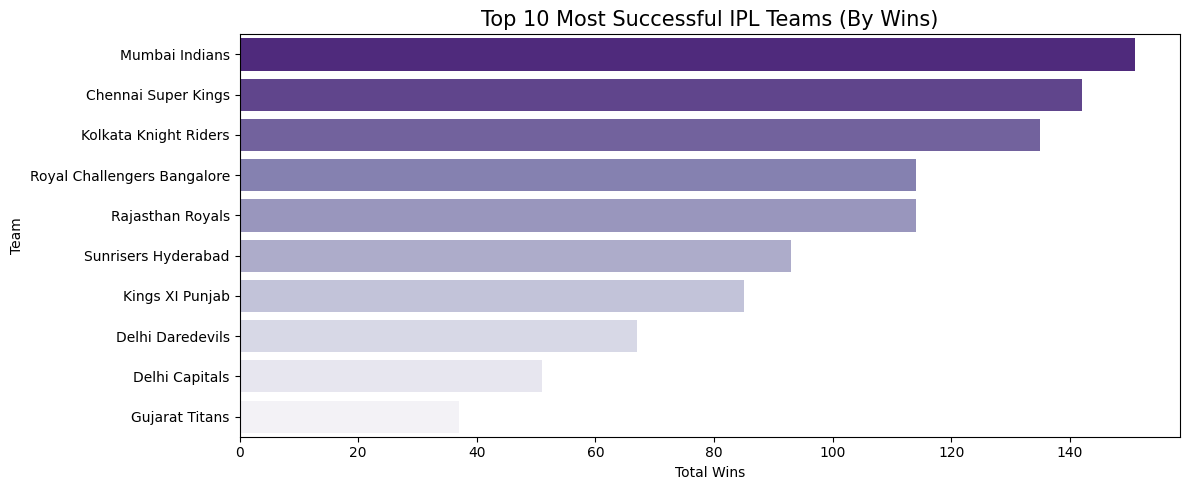

match_won_by
Mumbai Indians                 151
Chennai Super Kings            142
Kolkata Knight Riders          135
Royal Challengers Bangalore    114
Rajasthan Royals               114
Sunrisers Hyderabad             93
Kings XI Punjab                 85
Delhi Daredevils                67
Delhi Capitals                  51
Gujarat Titans                  37
Name: count, dtype: int64


In [16]:
# Most wins by team
team_wins = matches[matches['match_won_by'].notna()].drop_duplicates('match_id')
team_wins = team_wins['match_won_by'].value_counts().head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=team_wins.values, y=team_wins.index, hue=team_wins.index, palette='Purples_r', legend=False)
plt.title('Top 10 Most Successful IPL Teams (By Wins)', fontsize=15)
plt.xlabel('Total Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

print(team_wins)


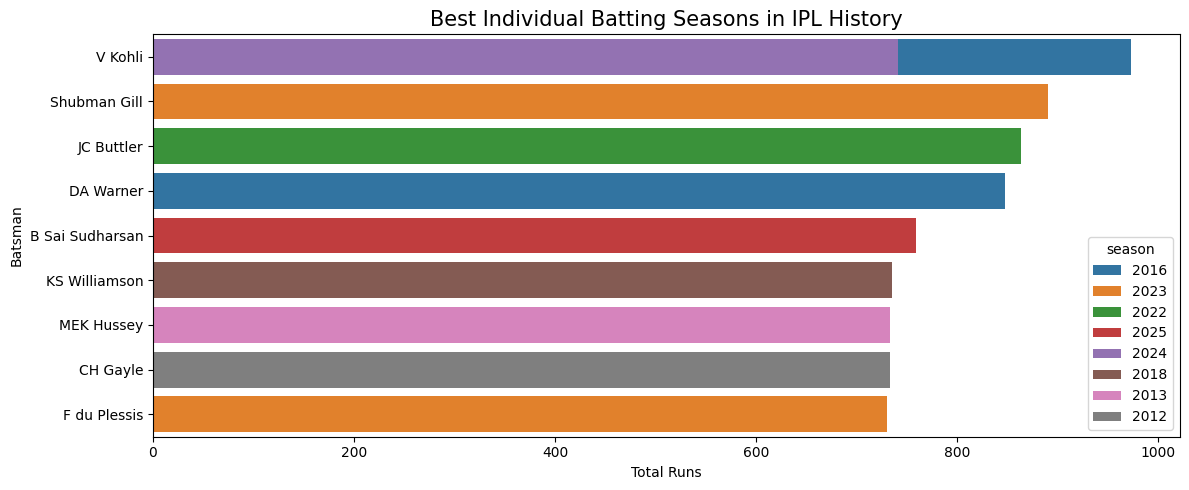

season          batter  runs_batter
  2016         V Kohli          973
  2023    Shubman Gill          890
  2022      JC Buttler          863
  2016       DA Warner          848
  2025 B Sai Sudharsan          759
  2024         V Kohli          741
  2018   KS Williamson          735
  2013      MEK Hussey          733
  2012        CH Gayle          733
  2023    F du Plessis          730


In [17]:
# Top run scorers per season
season_runs = matches.groupby(['season', 'batter'])['runs_batter'].sum().reset_index()
best_season = season_runs.sort_values('runs_batter', ascending=False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(x='runs_batter', y='batter', hue='season', data=best_season, dodge=False, legend=True)
plt.title('Best Individual Batting Seasons in IPL History', fontsize=15)
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()

print(best_season[['season', 'batter', 'runs_batter']].to_string(index=False))

Virat Kohli's 2016 season is the greatest individual batting season
in IPL history with 973 runs — a record that still stands in 2025.
Shubman Gill's 2023 season (890 runs) is the closest anyone has come
to breaking it. Notably Kohli appears twice in the top 10, also scoring
741 runs in 2024, proving his consistency across a decade.

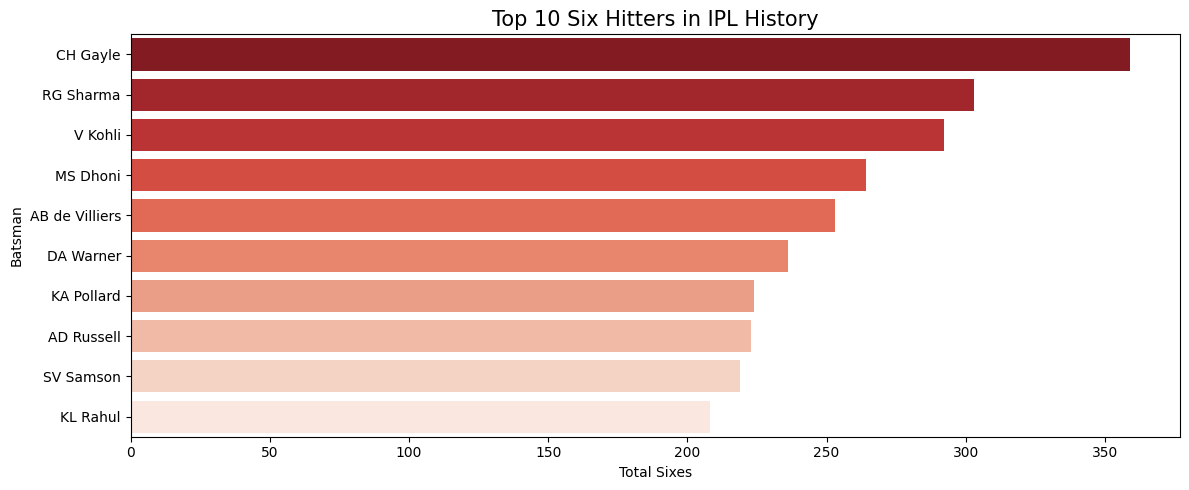

batter
CH Gayle          359
RG Sharma         303
V Kohli           292
MS Dhoni          264
AB de Villiers    253
DA Warner         236
KA Pollard        224
AD Russell        223
SV Samson         219
KL Rahul          208
Name: runs_batter, dtype: int64


In [18]:
# Top 10 six hitters of all time
sixes = matches[matches['runs_batter'] == 6]
top_six_hitters = sixes.groupby('batter')['runs_batter'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=top_six_hitters.values, y=top_six_hitters.index, hue=top_six_hitters.index, palette='Reds_r', legend=False)
plt.title('Top 10 Six Hitters in IPL History', fontsize=15)
plt.xlabel('Total Sixes')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()

print(top_six_hitters)

Chris Gayle is the undisputed six-hitting king of IPL with 359 sixes —
56 more than Rohit Sharma in second place (303). Gayle's ability to
clear the boundary at will made him the most feared T20 batsman of his
era. Interestingly Virat Kohli appears 3rd with 292 sixes, proving he
is not just a placement player but a powerful hitter too.

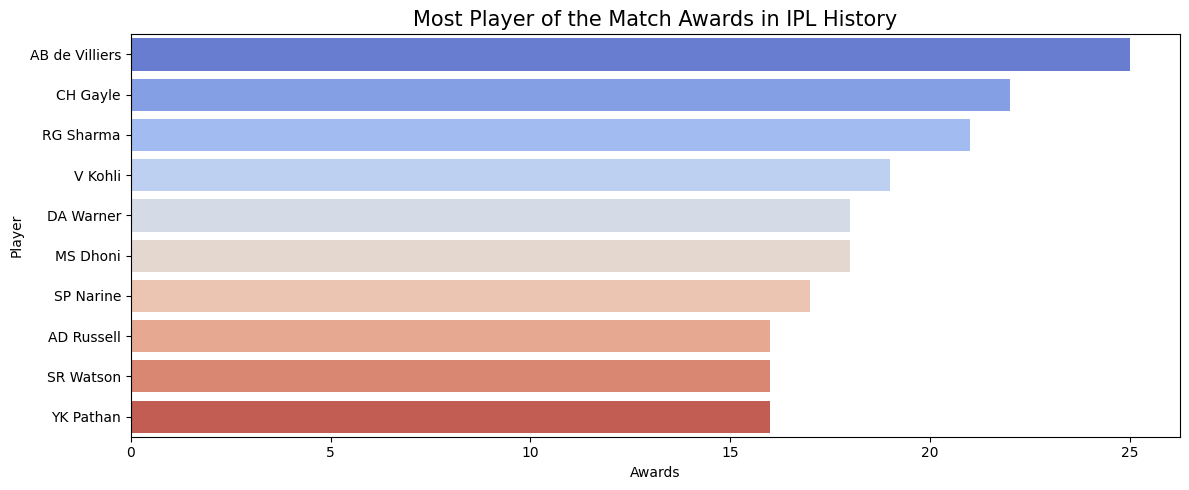

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         21
V Kohli           19
DA Warner         18
MS Dhoni          18
SP Narine         17
AD Russell        16
SR Watson         16
YK Pathan         16
Name: count, dtype: int64


In [19]:
# Most Player of the Match awards
potm = matches.drop_duplicates('match_id')
top_potm = potm['player_of_match'].value_counts().head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=top_potm.values, y=top_potm.index, hue=top_potm.index, palette='coolwarm', legend=False)
plt.title('Most Player of the Match Awards in IPL History', fontsize=15)
plt.xlabel('Awards')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

print(top_potm)

AB de Villiers leads all-time Player of the Match awards with 25,
ahead of Chris Gayle (22) and Rohit Sharma (21). De Villiers' ability
to win matches single-handedly across all conditions makes him the most
impactful IPL player ever despite never winning the title with RCB.
Notably Sunil Narine and Andre Russell both feature, highlighting
Kolkata Knight Riders' dependence on their foreign match winners.